# Mother machine: trap walls, single-file growth, and flush-out

The mother machine (Wang et al., *Current Biology* 2010) is a microfluidic
device that traps single rows of bacteria in narrow, dead-end channels: one
end is closed, the other opens onto a flowing feed channel. Each channel is
barely wider than one cell, so cells can't rotate or pass each other — they
grow single-file in a column. Growth pushes the whole column toward the open
end; the cell nearest the closed end (the "mother") stays put indefinitely,
while its descendants get carried away in the flow as soon as they cross the
open end.

This is exactly what `Environment`'s `wall_map` builds: walls (`1`) for the
closed end and the two long sides, and out-of-bounds (`-1`) for the open
end, so a cell that drifts there is removed — standing in for being carried
away by the feed channel's flow. This notebook builds that trap, places a
single cell carrying the repressilator network (see
`repressilator_demo.ipynb`) at the closed end, and runs the simulation for
many oscillator periods, watching growth, division, wall confinement, and
flush-out play out together.


In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, ReactionNetwork, Simulation
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100


## 1. The repressilator reaction network

The same three-gene inhibitory cycle (`A -| B -| C -| A`) as
`repressilator_demo.ipynb`, reused as-is here: it's the reporter for this
notebook, not the subject. See that notebook for the derivation of the
oscillatory regime.


In [2]:
def repression_rate(reactant_conc, product_conc, catalyst_conc, params):
    repressor = catalyst_conc.get(params["repressor"], 0.0)
    return params["beta"] / (1.0 + (repressor / params["K"]) ** params["n"])

# Kinetic parameters
beta, K, n, k_deg = 10.0, 1.0, 4.0, 1.0

# Three-gene inhibitory cycle: A -| B -| C -| A
gene_a = Reaction({}, {"A": 1}, catalysts=["C"], rate_law_type="custom",
                  custom_rate_law=repression_rate,
                  rate_params={"repressor": "C", "K": K, "n": n, "beta": beta})
gene_b = Reaction({}, {"B": 1}, catalysts=["A"], rate_law_type="custom",
                  custom_rate_law=repression_rate,
                  rate_params={"repressor": "A", "K": K, "n": n, "beta": beta})
gene_c = Reaction({}, {"C": 1}, catalysts=["B"], rate_law_type="custom",
                  custom_rate_law=repression_rate,
                  rate_params={"repressor": "B", "K": K, "n": n, "beta": beta})
deg_a = Reaction({"A": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
deg_b = Reaction({"B": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})
deg_c = Reaction({"C": 1}, {}, rate_law_type="mass_action", rate_params={"k": k_deg})

reactions = {"gene_a": gene_a, "gene_b": gene_b, "gene_c": gene_c,
             "deg_a": deg_a, "deg_b": deg_b, "deg_c": deg_c}


## 2. Baseline oscillation period

Before adding growth and walls, confirm the network still oscillates as
expected in a plain, unconfined cell — the same check
`repressilator_demo.ipynb` runs, condensed to the one number needed here:
the period, in time units, used below to size the trap run's `t_max`.


In [3]:
probe_cell = Cell(
    id=0, position=[5.0, 5.0], orientation=[1.0, 0.0],
    network=ReactionNetwork("repressilator", reactions),
    growth_rate=0.0, rng=np.random.default_rng(0),
)
probe_cell.set_concentration("A", 3.0)
probe_cell.set_concentration("B", 0.1)
probe_cell.set_concentration("C", 0.1)

probe_colony = Colony([probe_cell], Environment("probe", wall_map=np.zeros((5, 5)), size=(50.0, 50.0)))
df_probe = Simulation(probe_colony, dt=0.05, t_max=60.0).run(show_progress=False)

steady = df_probe[df_probe["time"] > 10.0]
a_vals, times = steady["A"].values, steady["time"].values
peaks = [i for i in range(1, len(a_vals) - 1)
         if a_vals[i] > a_vals[i-1] and a_vals[i] > a_vals[i+1]]
period = np.mean([times[peaks[i+1]] - times[peaks[i]] for i in range(len(peaks) - 1)])
print(f"estimated period: {period:.2f} time units")


estimated period: 6.00 time units


## 3. Trap geometry: a `wall_map` for a mother-machine channel

Building the trap is exactly what `wall_map` is for:

- **North** (closed end): wall (`1`).
- **East / West**: wall (`1`), spaced exactly `2 * radius` apart so the
  channel fits one cell and nothing wider — the "single-file" constraint.
- **South** (open end): out of bounds (`-1`). The feed channel's flow isn't
  itself simulated, but any cell whose center reaches it is removed, which
  stands in for being carried away.
- **Interior**: media (`0`).


trap_size = (3.0, 17.0) um, wall_map shape = (17, 3)
3 wall faces, 4 corner points


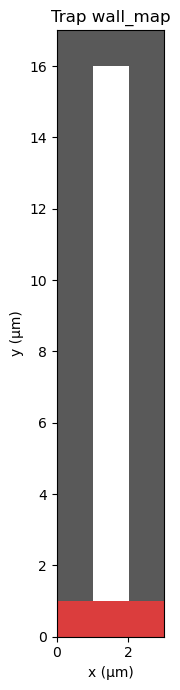

In [4]:
CELL_RADIUS = 0.5   # um, matches Cell's default radius
CELL_LENGTH = 2.0   # um, matches Cell's default length

TRAP_WIDTH = 2 * CELL_RADIUS   # single-file: fits exactly one cell across
TRAP_HEIGHT = 15.0              # um of usable (media) channel length
ROW_HEIGHT = 1.0                 # um per grid row

n_cols = 3                                          # west wall | media | east wall
interior_rows = int(round(TRAP_HEIGHT / ROW_HEIGHT))
n_rows = interior_rows + 2                          # + north wall row + south outflow row

wall_map = np.zeros((n_rows, n_cols))
wall_map[:, 0] = 1     # west wall
wall_map[:, -1] = 1    # east wall
wall_map[-1, :] = 1    # north wall: the trap's closed end
wall_map[0, :] = -1    # south row: the open end, out of bounds

trap_size = (n_cols * TRAP_WIDTH, n_rows * ROW_HEIGHT)
env = Environment("Trap", wall_map=wall_map, size=trap_size, eta=1.0)

print(f"trap_size = {trap_size} um, wall_map shape = {wall_map.shape}")
print(f"{len(env.wall_faces)} wall faces, {len(env.wall_corners)} corner points")

from matplotlib.colors import BoundaryNorm, ListedColormap

# Same palette Simulation.visualize_colony() paints the trap with below:
# media white, wall gray, out-of-bounds red.
cmap = ListedColormap([(0.86, 0.24, 0.24), (1.0, 1.0, 1.0), (0.35, 0.35, 0.35)])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(2.2, 7))
ax.imshow(wall_map, origin="lower", cmap=cmap, norm=norm,
          extent=[0, trap_size[0], 0, trap_size[1]])
ax.set_xlabel("x (μm)")
ax.set_ylabel("y (μm)")
ax.set_title("Trap wall_map")
fig.tight_layout()
plt.show()


## 4. A cell anchored at the closed (north) end

The cell starts near the closed end, oriented `(0, 1)` (pointing north) so
it grows lengthwise along the channel rather than across it — the only
orientation the channel's width actually allows. It carries the same
repressilator network as above, plus a nonzero `growth_rate` so it actually
divides over the run (the repressilator demo's single-cell sections set
`growth_rate=0.0` to isolate the oscillator; here growth driving division
is the point).

The channel is exactly one cell diameter wide, so it's already about as
confined as geometry gets; `Colony(..., brownian_motion=False)` turns off
thermal jitter on top of that, so growth, division, and wall contact are the
only things moving cells -- a cleaner picture of single-file wall
confinement on its own.


In [5]:
cell = Cell(
    id=0, position=[trap_size[0] / 2, TRAP_HEIGHT - 0.5], orientation=[0.0, 1.0],
    length=CELL_LENGTH, radius=CELL_RADIUS,
    network=ReactionNetwork("repressilator", reactions),
    growth_rate=0.04, rng=np.random.default_rng(19),
)
cell.set_concentration("A", 3.0)
cell.set_concentration("B", 0.1)
cell.set_concentration("C", 0.1)

colony = Colony([cell], env, k=10.0, drag=1.0, brownian_motion=False)


## 5. Running for many periods

With `growth_rate=0.04` and the default adder increment (`delta_bar=1.0`),
a cell divides roughly every ~10 time units; at ~`period` time units per
oscillation, 20 periods gives many generations' worth of time to grow,
divide, and get pushed out the open end.


In [6]:
N_PERIODS = 20
t_max = N_PERIODS * period

sim = Simulation(colony, dt=0.05, t_max=t_max, simulation_method="SSA")
df = sim.run(show_progress=False)

final = df[df["time"] == df["time"].max()]
total_cells = df["cell_id"].nunique()
alive_now = int(final["alive"].sum())
print(f"ran {t_max:.1f} time units (~{N_PERIODS} repressilator periods)")
print(f"{total_cells} cells total; {alive_now} remain in the trap; "
      f"{total_cells - alive_now} were flushed out the open end")


ran 120.0 time units (~20 repressilator periods)
61 cells total; 7 remain in the trap; 54 were flushed out the open end


## 6. Population size over time

Divisions and flush-outs happen on different, overlapping cadences, so
population size is noisy rather than perfectly periodic, but it settles
into a range set by how many cells the 10 μm trap can hold single-file at
once — never running dry, since the cell nearest the wall keeps growing and
dividing to replace whatever leaves at the open end.


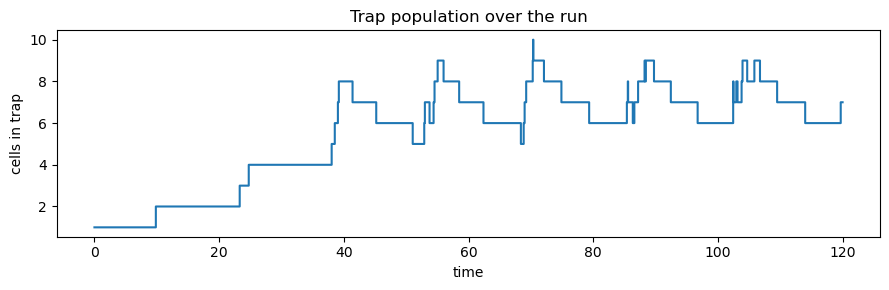

In [7]:
population = df.groupby("time")["alive"].sum()

fig, ax = plt.subplots(figsize=(9, 3))
ax.step(population.index, population.values, where="post")
ax.set_xlabel("time")
ax.set_ylabel("cells in trap")
ax.set_title("Trap population over the run")
fig.tight_layout()
plt.show()


## 7. Animating the trap

Three-color `visualize_colony()` maps `[A]`/`[B]`/`[C]` to red/green/blue,
as in `repressilator_demo.ipynb`. Watch the column of cells grow single-file
against the closed (north) wall, divide, and get carried out through the
open (south) end, tinted red for out of bounds.


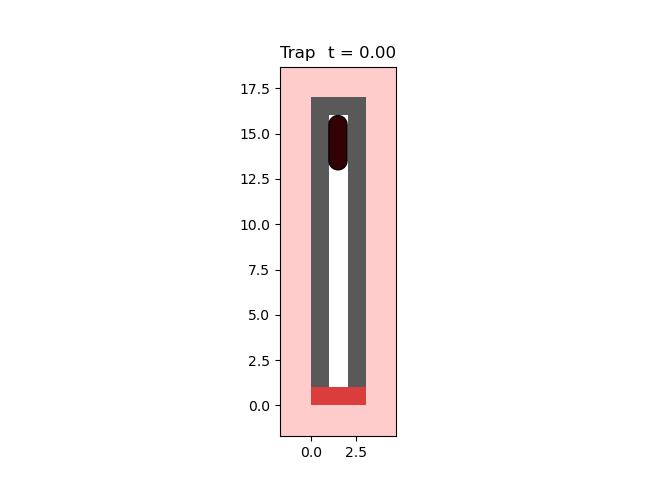

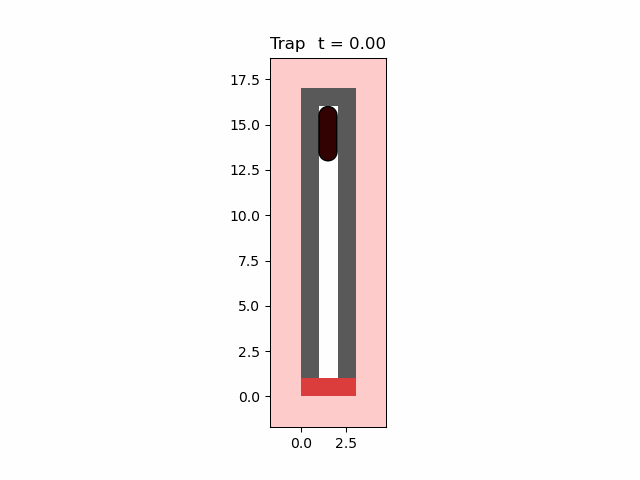

In [8]:
stride = max(1, round(len(df["time"].unique()) / 200))

sim.visualize_colony(
    red="A", green="B", blue="C",
    interval=60, stride=stride,
    save_path="outputs", filename="mother_machine.gif", show_progress=False,
)

with open("outputs/mother_machine_demo.pkl", "wb") as f:
    pickle.dump(df, f)
Image(filename="outputs/mother_machine.gif")
